In [2]:
import os, sys, imaplib, pathlib
import json
from google.colab import drive
drive.mount('/content/drive')#打开左侧文件夹查看位置!


Mounted at /content/drive


In [3]:
!pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.5 MB/s eta 0:00:00


In [4]:
!pip uninstall -y deepface tensorflow keras
!pip install -q deepface

Found existing installation: deepface 0.0.99
Uninstalling deepface-0.0.99:
  Successfully uninstalled deepface-0.0.99
Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 136.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 34.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpc-google-iam-v1 0.14.3 requires protobuf!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
o

In [5]:
import tensorflow as tf
print(tf.__version__)

from deepface import DeepFace
print(DeepFace.__version__)

2.21.0
26-03-23 12:44:32 - Directory /root/.deepface has been created
26-03-23 12:44:32 - Directory /root/.deepface/weights has been created
0.0.99


## input_output

In [ ]:
DATA_FOLDER="/content/drive/MyDrive/airbnbMM2/host_about/data_processed"
IMAGES_FOLDER="/content/drive/MyDrive/airbnbMM2/host_pic/images"

os.makedirs(IMAGES_FOLDER, exist_ok=True)

input_output={}
for folder in [ f for f in os.listdir(DATA_FOLDER) if not f.endswith('.csv')]:
    # folder = city_time

    # ---listings---
    files=os.listdir(os.path.join(DATA_FOLDER, folder))
    for f in files:
        if f.startswith('listings_processed'):
            path_listings=os.path.join(DATA_FOLDER, folder, f)
            path_listings_zsc=os.path.join(DATA_FOLDER, folder, f"listings_zsc_{folder}.csv")
    path_results_zsc=os.path.join(DATA_FOLDER, folder, f"resultsZSC_{folder}.csv")

    # ---images folder---
    pic_folder=os.path.join(IMAGES_FOLDER, folder)
    os.makedirs(pic_folder, exist_ok=True)

    # --resultsface---
    resultsFACE_folder=os.path.join(IMAGES_FOLDER, 'results')
    os.makedirs(resultsFACE_folder, exist_ok=True)

    path_results_face=os.path.join(resultsFACE_folder, f"face_{folder}.json")
    path_results_deepface=os.path.join(resultsFACE_folder, f"deepface_{folder}.json")

    # ---gather---
    input_output[folder]={"listings":path_listings,
              "results_zsc":path_results_zsc,
              "listings_zsc":path_listings_zsc,

              'pic_folder':pic_folder,
              'results_face':path_results_face,
              "results_deepface":path_results_deepface}

for k,v in input_output.items():
    print(f"{k}".center(100,'-'))
    path_listings=v['listings']
    path_results_zsc=v['results_zsc']
    path_listings_zsc=v['listings_zsc']

    pic_folder=v['pic_folder']
    path_results_face=v['results_face']
    path_results_deepface=v['results_deepface']

    print(path_listings)
    print(path_results_zsc)
    print(path_listings_zsc,"\n")
    print("pic folder:",pic_folder)
    print(path_results_face)
    print(path_results_deepface,"\n")

## APPLI BY BATCH

In [ ]:
import os
import json
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
from tqdm.contrib.concurrent import thread_map
from collections import Counter
from deepface import DeepFace

# ----------------- 工具函数 -----------------
def age_to_class(age):
    if age == "unk" or age is None:
        return 'unk'#之前是None！
    elif age < 30:
        return "young"
    elif age < 50:
        return "middle"
    else:
        return "senior"



# 单张图片处理函数
def process_one(item, pic_folder):
    img_path=os.path.join(pic_folder, f"{item['host_id']}.jpg")
    # filename = os.path.basename(item["img_path"].replace("\\", "/"))
    # img_path = os.path.join(image_folder, filename)

    row = {
        "img_path": img_path,
        "host_id": item["host_id"],
        "has_face": item.get("has_face", 0),
        "nb_face": item.get("nb_face", 0),
        "face_area_ratio": item.get("face_area_ratio"),
        "avg_face_prob": item.get("avg_face_prob"),
        "bbox_list": item.get("bbox_list", []),
        "clean_score": item.get("clean_score"),
        "lifestyle_score": item.get("lifestyle_score"),
        "host_picture_type": item.get("host_picture_type"),

        "age": item.get('age'),
        "age_class": item.get('age_class'),
        "gender": item.get('gender'),
        "smile_score": item.get('smile_score'),
        "is_smiling": item.get('is_smiling'),
        "dominant_emotion": item.get('dominant_emotion'),
    }


    # ---safe check--- (if processed, skip)
    if item.get('smile_score')!=0:
      return row

    # no face, init
    if item.get('has_face')==0:
      row['age'], row['age_class'], row['gender'],row['smile_score'], row['is_smiling'],row['dominant_emotion']=None, None, None, 0, 0, None


    # 至少一张脸
    else :
      try:
        analysis = DeepFace.analyze(
            img_path=img_path,
            actions=['age','gender','emotion'],
            enforce_detection=False,
            detector_backend="opencv",
        )

        # parse res
        if isinstance(analysis, dict):
            analysis = [analysis]

        ages, smiles, emotions, genders = [], [], [], []

        for face_analysis in analysis:
            ages.append(face_analysis.get("age", 0))
            smiles.append(face_analysis.get("emotion", {}).get("happy", 0))
            emotions.append(face_analysis.get("dominant_emotion", "neutral"))
            genders.append(face_analysis.get("dominant_gender", "unk"))

        # ---age---
        row["age"] = int(sum(ages)/len(ages))
        row["age_class"] = age_to_class(row["age"])

        # ---gender---
        gender_counts = Counter(genders)
        if len(gender_counts) == 1:
            row["gender"] = genders[0]
        else:
            row["gender"] = "multi"

        # ---smile---
        row["smile_score"] = float(sum(smiles)/len(smiles))
        row["is_smiling"] = 1 if row["smile_score"] > 40 else 0

        # ---dominant_emotion---
        emotion_counts = Counter(emotions)
        row["dominant_emotion"] = emotion_counts.most_common(1)[0][0]

      except Exception as e:
          print(f"[ERROR] {e}\n")
          row['age'], row['age_class'], row['gender'],row['smile_score'], row['is_smiling'],row['dominant_emotion']=None, None, None, 0, 0, None

    return row




In [ ]:
def run_deepface(
    pic_folder,
    path_results_face,
    path_results_deepface,
    n_sample=None,
    max_workers=4,
    save_interval=50
):

    # ---face---
    with open(path_results_face, "r", encoding="utf-8") as f:
        results_face = json.load(f)
    if n_sample:
        results_face = results_face[:n_sample]

    # ---deepface---
    if os.path.exists(path_results_deepface):
        print(f"[check] path deepface exists :{path_results_deepface}")
        with open(path_results_deepface, "r", encoding="utf-8") as f:
            results_deepface = json.load(f)
        processed_ids = set([int(r["host_id"]) for r in results_deepface])
        print(f"[info] {len(processed_ids)}/ {len(results_face)} images already processed, will skip them.\n")
    else:
        results_deepface = []
        processed_ids = set()

    # ---pending---
    pending = [item for item in results_face if int(item["host_id"]) not in processed_ids]
    print(f"[info] {len(pending)}/{len(results_face)} images to process!\n")

    if len(pending)>0 :
      # -------- 多线程 + tqdm -----------
      start_time = time.time()
      processed_count = 0
      with ThreadPoolExecutor(max_workers=max_workers) as executor:
          futures = {executor.submit(process_one, item, pic_folder): item for item in pending}
          for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images..."):
              row = future.result()
              results_deepface.append(row)
              processed_count += 1

              # 定期保存
              if processed_count % save_interval == 0:
                  with open(path_results_deepface, "w", encoding="utf-8") as f:
                      json.dump(results_deepface, f, indent=2, ensure_ascii=False)
                  print(f"[interval save] {processed_count} / {len(pending)} images processed and saved.")

      # -------- final save --------
      with open(path_results_deepface, "w", encoding="utf-8") as f:
          json.dump(results_deepface, f, indent=2, ensure_ascii=False)
          print(f"[final save] {processed_count} / {len(pending)} processed and saved.")

      end_time = time.time()
      total_time = end_time - start_time
      avg_time = total_time / max(len(pending), 1)

      print(f"\n[DONE] {len(pending)} images processed in {total_time:.2f} sec, saved to {path_results_deepface}!")
      print(f"Average time per image: {avg_time:.2f} sec\n")
    else :
      print(f"[info] all processed! go to clean!\n")

      # check
      results_deepface_clean=[]
      for row in results_deepface:
        if row['has_face']==0:
          row['age'], row['age_class'], row['gender'],row['smile_score'], row['is_smiling'],row['dominant_emotion']=None, None, None, 0, 0, None
        #   row['age'], row['age_class'], row['gender'],row['smile_score'], row['is_smiling'],row['dominant_emotion']= None, "unk", "unk", 0, 0, None
          results_deepface_clean.append(row)
        else:
          results_deepface_clean.append(row)
      # -------- clean save --------
      with open(path_results_deepface, "w", encoding="utf-8") as f:
          json.dump(results_deepface_clean, f, indent=2, ensure_ascii=False)
          print(f"[final save] {len(results_deepface_clean)} cleaned and saved to {path_results_deepface}!\n")

    return results_deepface



## test

In [51]:
paths=input_output['paris_2406']

pic_folder=paths['pic_folder']
path_results_face=paths['results_face']
path_results_deepface=paths['results_deepface']

# 中断程序会导致写到一半，文件损坏！
results_deepface = run_deepface(
    pic_folder,
    path_results_face,
    path_results_deepface,
    n_sample=None,
    max_workers=4,
    save_interval=1000
)

[check] path deepface exists :/content/drive/MyDrive/airbnbMM2/host_pic/images/results/deepface_paris_2406.json
[info] 43074/ 43074 images already processed, will skip them.

[info] 0/43074 images to process!

[info] all processed! go to clean!

[final save] 43074 cleaned and saved to /content/drive/MyDrive/airbnbMM2/host_pic/images/results/deepface_paris_2406.json!



## appli:

In [9]:
for i, paths in input_output.items():
  print(f"{i}".center(100, '='))
  pic_folder=paths['pic_folder']
  path_results_face=paths['results_face']
  path_results_deepface=paths['results_deepface']
  # print(path_results_deepface)
  results_deepface = run_deepface(
      pic_folder,
      path_results_face,
      path_results_deepface,
      n_sample=None,
      max_workers=4,
      save_interval=1000
  )




=============================================paris_2306=============================================
[check] path deepface exists :/content/drive/MyDrive/airbnbMM2/host_pic/images/results/deepface_paris_2306.json
[info] 21652/ 21652 images already processed, will skip them.

[info] 0/21652 images to process!

[info] all processed! go to clean!

[final save] 21652 cleaned and saved to /content/drive/MyDrive/airbnbMM2/host_pic/images/results/deepface_paris_2306.json!

============================================london_2406=============================================
[check] path deepface exists :/content/drive/MyDrive/airbnbMM2/host_pic/images/results/deepface_london_2406.json
[info] 24885/ 24885 images already processed, will skip them.

[info] 0/24885 images to process!

[info] all processed! go to clean!

[final save] 24885 cleaned and saved to /content/drive/MyDrive/airbnbMM2/host_pic/images/results/deepface_london_2406.json!

============================================london_2306=

In [ ]:
## add 'in_paris'+"in_2024"
import pandas as pd
results_all=pd.DataFrame()

for i, paths in input_output.items():
  print(f"{i}".center(100, '='))
  in_paris = 1 if i.split('_')[0]=='paris' else 0
  in_2024 = 1 if i.split('_')[1].startswith('24') else 0
  path_results_deepface=paths['results_deepface']
  with open(path_results_deepface, "r", encoding="utf-8") as f:
    results_deepface = json.load(f)
    print(f'len results {i}: ',len(results_deepface))

  results_df=pd.DataFrame(results_deepface)
  results_df['in_paris']=in_paris
  results_df['in_2024']=in_2024
  print(results_df[['in_paris','in_2024']].value_counts(dropna=False))

  results_all=pd.concat([results_all, results_df], axis=0)
  print('len results all:',results_all.shape)
  # display(results_df.head(),"\n")

  # break

=============================================paris_2306=============================================
len results paris_2306:  21652
is_paris  in_2024
1         0          21652
Name: count, dtype: int64
len results all: (21652, 18)
============================================london_2406=============================================
len results london_2406:  24885
is_paris  in_2024
0         1          24885
Name: count, dtype: int64
len results all: (46537, 18)
============================================london_2306=============================================
len results london_2306:  21996
is_paris  in_2024
0         0          21996
Name: count, dtype: int64
len results all: (68533, 18)
=============================================paris_2406=============================================
len results paris_2406:  43074
is_paris  in_2024
1         1          43074
Name: count, dtype: int64
len results all: (111607, 18)


In [19]:
results_all.head()

,img_path,host_id,has_face,nb_face,face_area_ratio,avg_face_prob,bbox_list,clean_score,lifestyle_score,host_picture_type,age,age_class,gender,smile_score,is_smiling,dominant_emotion,is_paris,in_2024
0,/content/drive/MyDrive/airbnbMM2/host_pic/imag...,513298634,0,0,0.000000,0.000000,[],0.000000,0.000000,no_person,NaN,None,None,0.000000e+00,0,None,1,0
1,/content/drive/MyDrive/airbnbMM2/host_pic/imag...,32437290,1,2,0.209837,0.998093,"[[45, 0, 112, 79], [119, 6, 184, 88]]",0.000000,0.000000,life_style,29.0,young,Man,7.583961e-05,0,sad,1,0
2,/content/drive/MyDrive/airbnbMM2/host_pic/imag...,513756068,1,1,0.047111,0.997664,"[[98, 49, 143, 102]]",0.155508,0.133369,pro_style,29.0,young,Man,1.799005e-14,0,fear,1,0
3,/content/drive/MyDrive/airbnbMM2/host_pic/imag...,493875512,0,0,0.000000,0.000000,[],0.000000,0.000000,no_person,NaN,None,None,0.000000e+00,0,None,1,0
4,/content/drive/MyDrive/airbnbMM2/host_pic/imag...,513550634,1,1,0.251457,0.999999,"[[66, 39, 161, 173]]",0.269232,0.048076,pro_style,37.0,middle,Woman,9.994334e+01,1,happy,1,0


In [18]:
path_results_all="/content/drive/MyDrive/airbnbMM2/host_pic/images/results/deepface_all.csv"
results_all.to_csv(path_results_all, index=False)


## VIS

In [3]:
import pandas as pd
path_results_deepface=r"images\results\deepface_all.csv"
results=pd.read_csv(path_results_deepface)
print(results.shape)
display(results.head())

(111607, 18)


,img_path,host_id,has_face,nb_face,face_area_ratio,avg_face_prob,bbox_list,clean_score,lifestyle_score,host_picture_type,age,age_class,gender,smile_score,is_smiling,dominant_emotion,in_paris,in_2024
0,/content/drive/MyDrive/airbnbMM2/host_pic/imag...,513298634,0,0,0.000000,0.000000,[],0.000000,0.000000,no_person,NaN,NaN,NaN,0.000000e+00,0,NaN,1,0
1,/content/drive/MyDrive/airbnbMM2/host_pic/imag...,32437290,1,2,0.209837,0.998093,"[[45, 0, 112, 79], [119, 6, 184, 88]]",0.000000,0.000000,life_style,29.0,young,Man,7.583961e-05,0,sad,1,0
2,/content/drive/MyDrive/airbnbMM2/host_pic/imag...,513756068,1,1,0.047111,0.997664,"[[98, 49, 143, 102]]",0.155508,0.133369,pro_style,29.0,young,Man,1.799005e-14,0,fear,1,0
3,/content/drive/MyDrive/airbnbMM2/host_pic/imag...,493875512,0,0,0.000000,0.000000,[],0.000000,0.000000,no_person,NaN,NaN,NaN,0.000000e+00,0,NaN,1,0
4,/content/drive/MyDrive/airbnbMM2/host_pic/imag...,513550634,1,1,0.251457,0.999999,"[[66, 39, 161, 173]]",0.269232,0.048076,pro_style,37.0,middle,Woman,9.994334e+01,1,happy,1,0


In [4]:
import os
import ast
import cv2
import random
import matplotlib.pyplot as plt
import ast


def safe_parse(x):
    if isinstance(x, str):
        return ast.literal_eval(x.strip())
    return x

def visualize_face_results(folder_images, results_df, host_picture_type=None, n_samples=30, seed=42):
    """
    随机可视化若干检测结果
    """
    if host_picture_type:
        print(f"ONLY visualise host pic:{host_picture_type}\n")
        results_df=results_df[results_df['host_picture_type']==host_picture_type]
    print(len(results_df))
    
    random.seed(seed)
    samples = results_df.sample(n=min(n_samples, len(results_df)), random_state=seed)
    samples["bbox_list"] = samples["bbox_list"].apply(safe_parse)

    n_cols = 5
    n_rows = (len(samples) + n_cols - 1) // n_cols

    plt.figure(figsize=(4*n_cols, 4*n_rows))

    for i, (_, item) in enumerate(samples.iterrows()):
        city="paris" if item['in_paris']==1 else 'london'
        time="2406" if item['in_2024']==1 else '2306'
        path_img=os.path.join(folder_images, f"{city}_{time}", f"{item['host_id']}.jpg")

        if not os.path.exists(path_img):
            print(f"path doesnt exist: {path_img} \n")
            continue 
        # print(item)
        
        img = cv2.imread(path_img)
        if img is None:
            continue
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # 画 bbox

        for j, bbox in enumerate(item["bbox_list"]):
            x1, y1, x2, y2 = bbox
            cv2.rectangle(img_rgb, (x1,y1), (x2,y2), (255,0,0), 2)

        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(img_rgb)
        plt.axis("off")


        # title = (
        #     # f"host_id: {item['host_id']} | city:{city} | time:{time}\n"
        #     # f"has_face={item['has_face']} | nb={item['nb_face']}\n"
        #     f"type={item['host_picture_type']}\n"
        #     f"smile_score={item['smile_score']:.2f}; similing={item['is_smiling']};\n" 
        #     # f"emotion={item['dominant_emotion']}\n"
        #     f"age_class={item['age_class']}; gender={item['gender']}\n"
        #     # f"area_ratio={round(item['face_area_ratio'],3)}\n"
        #     # f"avg_prob={round(item['avg_face_prob'],3)}\n"
        #     # f"clean_score={item['clean_score']:.2f} | lifestyle_scores={item['lifestyle_score']:.2f}\n"
        #     # f"emotion={item['dominant_emotion']}\n"
        # )
        # plt.title(title, fontsize=9)

    plt.tight_layout()
    plt.show()

    return


ONLY visualise host pic:no_person

20293


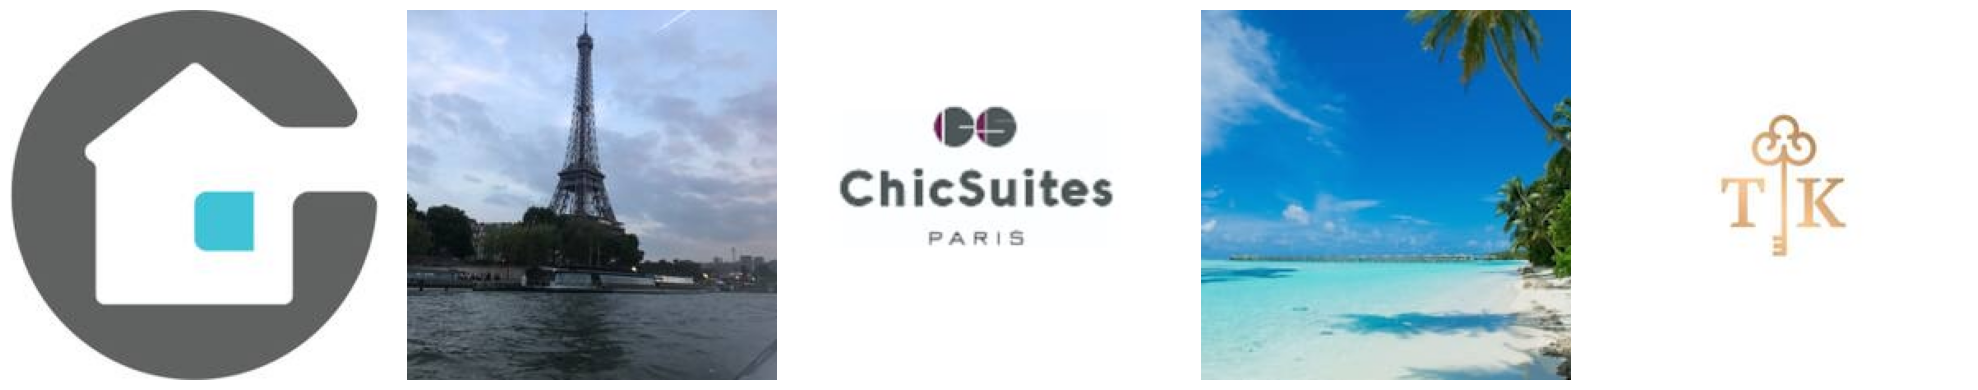

In [119]:
visualize_face_results(folder_images=r"../B_images\images",
                       host_picture_type='no_person',
                       results_df=results, n_samples=5, seed=25)# 42

ONLY visualise host pic:pro_style

50040


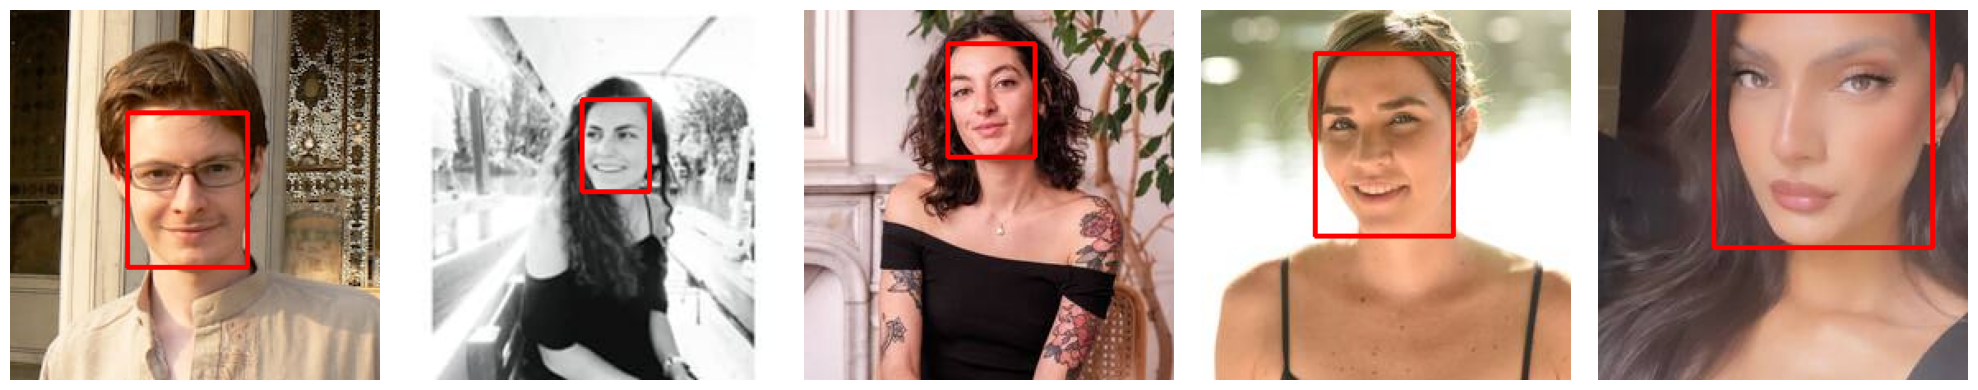

In [33]:
visualize_face_results(folder_images=r"../B_images\images",
                       host_picture_type='pro_style',
                       results_df=results, n_samples=5, seed=7)#7


ONLY visualise host pic:life_style

41274


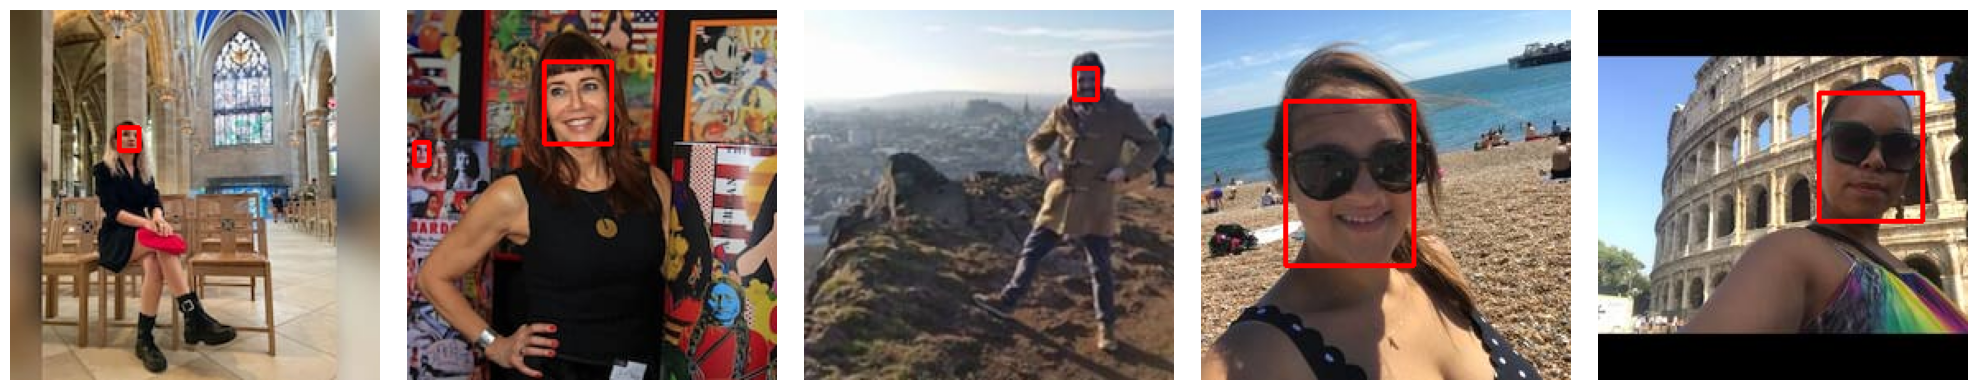

In [85]:
visualize_face_results(folder_images=r"../B_images\images",
                       host_picture_type='life_style',
                       results_df=results, n_samples=5, seed=21)# 21. 25.27.45


## merge

In [28]:
## 1) load df with tactics scores
import pandas as pd
df_all=pd.read_csv("../data_processed\listings_tactics-paris_london-2306_2406.csv")
print(df_all.shape)
print(df_all.columns.to_list())


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18668\3177141575.py:3: DtypeWarning: Columns (68) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv("../data_processed\listings_tactics-paris_london-2306_2406.csv")


(187851, 115)
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_9

In [29]:
## 2) laod face results
results=pd.read_csv(r"images\results\deepface_all.csv")
# results.rename(columns={"is_paris":"in_paris"}, inplace=True)
print(results.columns.to_list())


['img_path', 'host_id', 'has_face', 'nb_face', 'face_area_ratio', 'avg_face_prob', 'bbox_list', 'clean_score', 'lifestyle_score', 'host_picture_type', 'age', 'age_class', 'gender', 'smile_score', 'is_smiling', 'dominant_emotion', 'in_paris', 'in_2024']


In [30]:
results_to_merge=results[['host_id','in_paris','in_2024',"has_face","bbox_list","host_picture_type","age","age_class","gender","smile_score","is_smiling","dominant_emotion"]]
print(results_to_merge.shape)
display(results_to_merge.head())

(111607, 12)


,host_id,in_paris,in_2024,has_face,bbox_list,host_picture_type,age,age_class,gender,smile_score,is_smiling,dominant_emotion
0,513298634,1,0,0,[],no_person,NaN,NaN,NaN,0.000000e+00,0,NaN
1,32437290,1,0,1,"[[45, 0, 112, 79], [119, 6, 184, 88]]",life_style,29.0,young,Man,7.583961e-05,0,sad
2,513756068,1,0,1,"[[98, 49, 143, 102]]",pro_style,29.0,young,Man,1.799005e-14,0,fear
3,493875512,1,0,0,[],no_person,NaN,NaN,NaN,0.000000e+00,0,NaN
4,513550634,1,0,1,"[[66, 39, 161, 173]]",pro_style,37.0,middle,Woman,9.994334e+01,1,happy


In [31]:
df_merged=df_all.merge(results_to_merge, on=['host_id','in_paris','in_2024'], how='left')
print(df_merged.shape)
df_merged.head()

(187851, 124)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,exemplarité,has_face,bbox_list,host_picture_type,age,age_class,gender,smile_score,is_smiling,dominant_emotion
0,157714,https://www.airbnb.com/rooms/157714,20230608145305,2023-06-09,city scrape,Townhouse in Hammersmith · ★4.71 · 1 bedroom ·...,"Large, light and spacious loft bedroom with a ...",The neighbourhood is extremely convenient for ...,https://a0.muscache.com/pictures/4129744/10db5...,757377,...,0.196903,1.0,"[[6, 4, 107, 134], [71, 86, 149, 184]]",life_style,30.0,middle,Man,48.102501,1.0,happy
1,13913,https://www.airbnb.com/rooms/13913,20230608145305,2023-06-09,city scrape,Rental unit in Islington · ★4.80 · 1 bedroom ·...,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,-0.740246,1.0,"[[112, 44, 203, 160]]",pro_style,29.0,young,Man,99.988579,1.0,happy
2,15400,https://www.airbnb.com/rooms/15400,20230608145305,2023-06-09,city scrape,Rental unit in London · ★4.80 · 1 bedroom · 1 ...,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,1.322457,1.0,"[[17, 25, 41, 58], [42, 123, 65, 148]]",life_style,35.0,middle,Man,0.000002,0.0,fear
3,306333,https://www.airbnb.com/rooms/306333,20230608145305,2023-06-09,city scrape,Rental unit in London · ★4.32 · 2 bedrooms · 3...,Welcome to my lovely 2-bedroom flat in Hoxton!...,"In Shoreditch, empty walls are future murals. ...",https://a0.muscache.com/pictures/32c818d1-7762...,1573870,...,-0.652790,1.0,"[[59, 17, 165, 143]]",pro_style,30.0,middle,Man,3.950689,0.0,sad
4,159736,https://www.airbnb.com/rooms/159736,20230608145305,2023-06-09,city scrape,Rental unit in Lambeth · ★4.72 · 1 bedroom · 1...,Calm sunny double room with a queen size bed a...,We love that in Loughborough Junction we live ...,https://a0.muscache.com/pictures/1067303/d2300...,766056,...,0.632008,1.0,"[[46, 53, 154, 200]]",pro_style,31.0,middle,Man,93.137543,1.0,happy


In [32]:
# 无匹配填0 在smile_score, is_smiling上填0, 和tactics_bio一起填0!age_class和gender填unk
# 是否过滤无pic匹配？
df_merged[['in_paris','in_2024',"has_face",'bbox_list',"host_picture_type","age","age_class","gender","smile_score","is_smiling","dominant_emotion"]].value_counts(dropna=False)

in_paris  in_2024  has_face  bbox_list                                 host_picture_type  age   age_class  gender  smile_score   is_smiling  dominant_emotion
1         1        0.0       []                                        no_person          NaN   NaN        NaN     0.000000e+00  0.0         NaN                 16989
0         1        0.0       []                                        no_person          NaN   NaN        NaN     0.000000e+00  0.0         NaN                 15876
          0        0.0       []                                        no_person          NaN   NaN        NaN     0.000000e+00  0.0         NaN                 12842
1         0        0.0       []                                        no_person          NaN   NaN        NaN     0.000000e+00  0.0         NaN                  9809
          1        NaN       NaN                                       NaN                NaN   NaN        NaN     NaN           NaN         NaN                  3038
       

In [33]:
df_merged.to_csv("../data_processed\listings_tactics_bio_vis-paris_london-2306_2406.csv", index=False)